In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


sys.path.insert(0, "/data/keeling/a/jdnied2/c/598/rs-embed/src")
sys.path.insert(0, "/data/keeling/a/jdnied2/c/598/rs-embed/")

from examples.utils_demo import (
    ee_initialize,
    iter_export_points,
    iter_model_vectors,
    load_one_preview_patch,
    point_key,
    point_row_index,
    resolve_preview_group_dirs,
    rings_from_geom_info,
    stretch_rgb,
)
from rs_embed import OutputSpec, PointBuffer, TemporalSpec, export_batch

STATES = ["Minnesota", "South Dakota", "Kansas", 
          "Iowa", "Illinois", "Ohio", "Indiana", 
          "Missouri", "Wisconsin", "Kentucky"]

# Replace your path here
H_CSV = "/data/keeling/a/jdnied2/c/598/rs-embed/dataverse_files/Global_CSV/spam2020V2r0_global_harvested_area/spam2020V2r0_global_H_TA.csv"
Y_CSV = "/data/keeling/a/jdnied2/c/598/rs-embed/dataverse_files/Global_CSV/spam2020V2r0_global_yield/spam2020V2r0_global_Y_TA.csv"
EXPORT_ROOT = Path(os.getenv("DEMO_EXPORT_DIR", "./exports")).expanduser()

SPAM_CROP_COL = os.getenv("SPAM_CROP_COL", "MAIZ_A").upper()
COUNTRY_CODE = os.getenv("SPAM_COUNTRY_CODE", "US").upper()
# LABEL_YEAR = int(os.getenv("SPAM_LABEL_YEAR", "2020"))
MIN_AREA_HA = float(os.getenv("MAIZ_AREA_MIN_HA", "2500"))
BUFFER_M = int(os.getenv("BUFFER_M", "2000"))

# Select model as needed here
MODEL_LIST = [
    "terrafm",
    "satvision",
    "agrifm",
    "satmae"
]


EMBED_START = os.getenv("EMBED_START", "2019-06-01")
EMBED_END = os.getenv("EMBED_END", "2019-08-31")
TEMPORAL = TemporalSpec.range(EMBED_START, EMBED_END)

TEST_SIZE = float(os.getenv("REG_TEST_SIZE", "0.25"))
MIN_SAMPLES = int(os.getenv("MIN_MODEL_SAMPLES", "30"))

EE_PROJECT = os.getenv("EE_PROJECT")
EE_PROJECT = "cs-598-491115"
print(
    {
        "EXPORT_ROOT": str(EXPORT_ROOT),
        "MODEL_LIST": MODEL_LIST,
        # "LABEL_YEAR": LABEL_YEAR,
        "BUFFER_M": BUFFER_M,
        "TEMPORAL": [EMBED_START, EMBED_END],
    }
)

SAVE_INPUTS = bool(int(os.getenv("SAVE_INPUTS", "1")))

{'EXPORT_ROOT': 'exports', 'MODEL_LIST': ['terrafm', 'satvision', 'agrifm', 'satmae'], 'BUFFER_M': 2000, 'TEMPORAL': ['2019-06-01', '2019-08-31']}


In [2]:
import ee
out = ee.Initialize(project="cs-598-491115") 
print(out)

None


In [3]:
# rings_from_geom_info(roi_geom.getInfo())

In [4]:
def rings_from_geom_info(geom_info: dict):
    gtype = geom_info.get("type")
    coords = geom_info.get("coordinates", [])

    if gtype == "Polygon":
        # coords[0] = exterior boundary; coords[1:] = holes
        return [np.asarray(coords[0], dtype=float)]

    if gtype == "MultiPolygon":
        return [
            np.asarray(poly[0], dtype=float)
            for poly in coords
            if poly and poly[0]
        ]

    if gtype == "LineString":
        return [np.asarray(coords, dtype=float)]

    if gtype == "MultiLineString":
        return [
            np.asarray(line, dtype=float)
            for line in coords
            if line
        ]

    if gtype == "GeometryCollection":
        rings = []
        for geom in geom_info.get("geometries", []):
            rings.extend(rings_from_geom_info(geom))
        return rings

    # Skip anything else instead of crashing
    return []

<h1> Plot SPAM Maize State Dist. </h1>

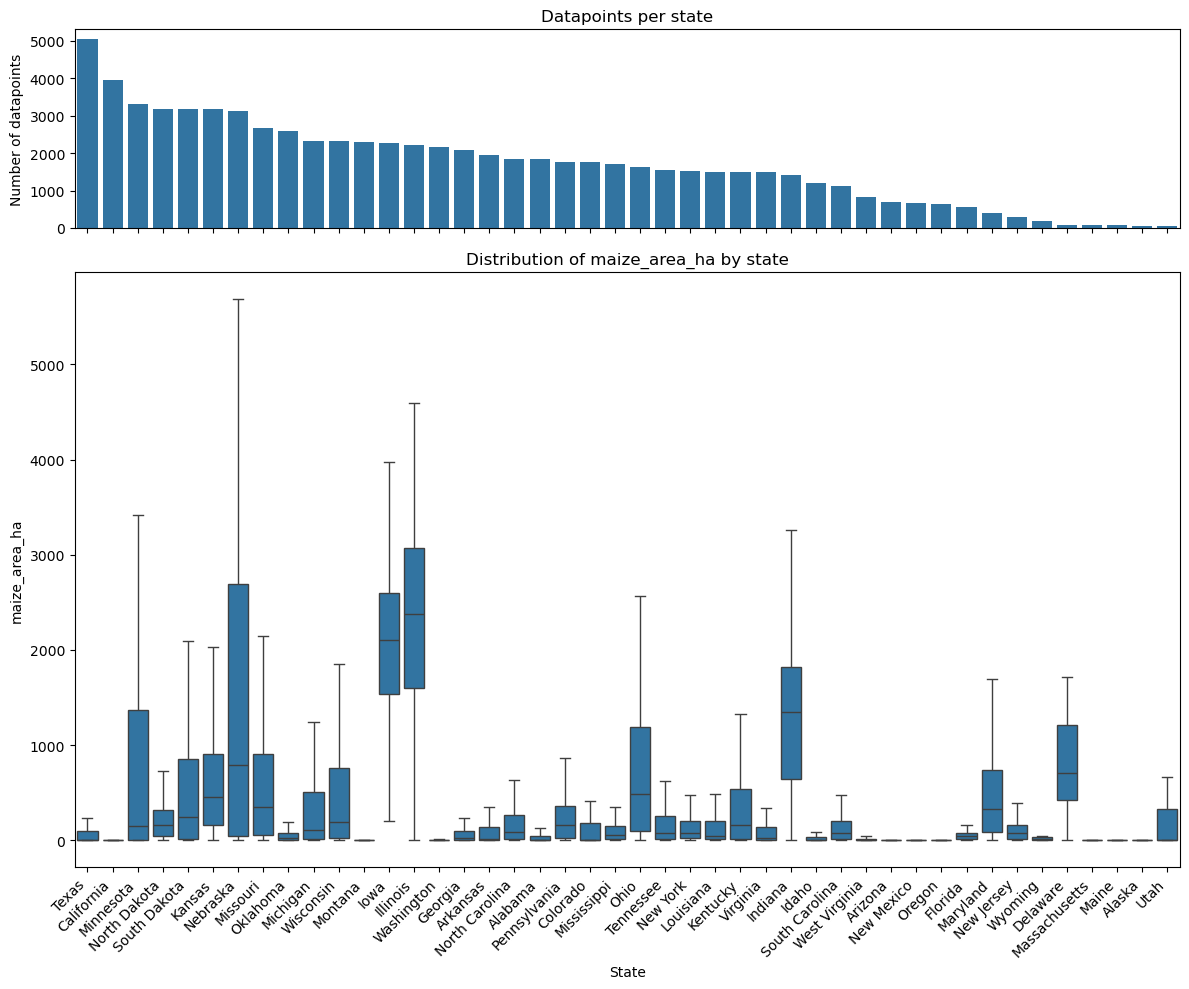

In [5]:
csv_path  = H_CSV
value_name="maize_area_ha"
usecols = ["grid_code", "x", "y", "FIPS0", "ADM1_NAME", "year_data", SPAM_CROP_COL]
table = pd.read_csv(csv_path, usecols=usecols, encoding="utf-8-sig")
table = table.rename(columns={"x": "lon", "y": "lat", SPAM_CROP_COL: value_name})

table["grid_code"] = table["grid_code"].astype(str)
table["FIPS0"] = table["FIPS0"].astype(str).str.upper()
table["ADM1_NAME"] = table["ADM1_NAME"].astype(str)
table["year_data"] = table["year_data"].astype(str)
table[value_name] = pd.to_numeric(table[value_name], errors="coerce")

table = table[
    table["FIPS0"].eq(COUNTRY_CODE)
    # & table["year_data"].str.contains(str(LABEL_YEAR), na=False)
]

counts_per_state = (
    table
    .groupby("ADM1_NAME")
    .size()
    .reset_index(name="n_datapoints")
)

state_order = counts_per_state.sort_values(
    "n_datapoints", ascending=False
)["ADM1_NAME"]

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)

# --- Top: counts per state ---
sns.barplot(
    data=counts_per_state,
    x="ADM1_NAME",
    y="n_datapoints",
    order=state_order,
    ax=axes[0]
)

axes[0].set_ylabel("Number of datapoints")
axes[0].set_title("Datapoints per state")

# --- Bottom: box + whisker ---
sns.boxplot(
    data=table,
    x="ADM1_NAME",
    y=value_name,
    order=state_order,
    ax=axes[1],
    showfliers=False  # cleaner; remove if you want outliers
)

axes[1].set_ylabel(value_name)
axes[1].set_xlabel("State")
axes[1].set_title(f"Distribution of {value_name} by state")

# Rotate labels
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

<h1>Get States Data from SPAM</h1>

In [6]:
def get_state_ring(STATE):
    try:
        import ee
    
        ee_initialize(ee, EE_PROJECT)
        states_fc = ee.FeatureCollection("TIGER/2018/States")
        roi_feat = states_fc.filter(ee.Filter.eq("NAME", STATE)).first()
        roi_geom = roi_feat.geometry()
        center_lon, center_lat = roi_geom.centroid(maxError=100).coordinates().getInfo()
        state_rings = rings_from_geom_info(roi_geom.getInfo())
        # print(f"ROI center: lon={center_lon:.4f}, lat={center_lat:.4f}")
        return state_rings, center_lon, center_lat, roi_geom
    except Exception as e:
        print("Boundary plot fallback:", e)

def draw_illinois_boundary(state_rings, ax, color="#222222", linewidth=1.1):
    for ring in state_rings:
        if ring.ndim == 2 and ring.shape[1] >= 2:
            ax.plot(ring[:, 0], ring[:, 1], color=color, linewidth=linewidth)
            
def plot_state(state_dict_rings, cent_dict, state):
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    draw_illinois_boundary(state_dict_rings[state], ax, color="#111111", linewidth=1.4)
    center_lon, center_lat = cent_dict[state]
    if np.isfinite(center_lon) and np.isfinite(center_lat):
        ax.scatter([center_lon], [center_lat], s=50, color="#d95f02", label="ROI centroid")
    ax.set_title(f"{state} boundary")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    if np.isfinite(center_lon) and np.isfinite(center_lat):
        ax.legend(loc="upper right")
    ax.grid(alpha=0.25)
    plt.show()


def load_spam_value(csv_path: Path, value_name: str, STATE_NAME: str) -> pd.DataFrame:
    usecols = ["grid_code", "x", "y", "FIPS0", "ADM1_NAME", "year_data", SPAM_CROP_COL]
    table = pd.read_csv(csv_path, usecols=usecols, encoding="utf-8-sig")
    table = table.rename(columns={"x": "lon", "y": "lat", SPAM_CROP_COL: value_name})

    table["grid_code"] = table["grid_code"].astype(str)
    table["FIPS0"] = table["FIPS0"].astype(str).str.upper()
    table["ADM1_NAME"] = table["ADM1_NAME"].astype(str)
    table["year_data"] = table["year_data"].astype(str)
    table[value_name] = pd.to_numeric(table[value_name], errors="coerce")

    table = table[
        table["FIPS0"].eq(COUNTRY_CODE)
        & table["ADM1_NAME"].str.contains(STATE_NAME, case=False, na=False)
        # & table["year_data"].str.contains(str(LABEL_YEAR), na=False)
    ]

    return table[["grid_code", "lon", "lat", value_name]].dropna()

In [7]:
# ring_dict = {}
# cent_coord_dict={}
all_state_dfs = []
state_spatials = {}
state_point_names  = {}

for STATE in STATES:

    # rings, lon, lat, _ = get_state_ring(STATE)
    # ring_dict[STATE] = rings
    # cent_coord_dict[STATE] = (lon, lat)
    
    # plot_state(ring_dict, cent_coord_dict, STATE)

    area_df = load_spam_value(H_CSV, "maize_area_ha", STATE_NAME=STATE)
    area_df = area_df[area_df["maize_area_ha"] >= MIN_AREA_HA].drop_duplicates("grid_code")
    
    yield_df = load_spam_value(Y_CSV, "label", STATE_NAME=STATE)
    yield_df = yield_df[yield_df["label"] > 0].drop_duplicates("grid_code")
    
    df = (
        area_df.merge(yield_df[["grid_code", "label"]], on="grid_code", how="inner")
        .sort_values(["lat", "lon"])
        .reset_index(drop=True)
    )
    
    if df.empty:
        raise RuntimeError("No Illinois points found after filtering.")

    df["state"] = STATE
    all_state_dfs.append(df)
    
    spatials = [
        PointBuffer(lon=float(row.lon), lat=float(row.lat), buffer_m=BUFFER_M)
        for row in df.itertuples(index=False)
    ]
    state_spatials[STATE] = spatials
    state_point_names[STATE] = [f"p{i:05d}" for i in range(len(spatials))]
    
    print(f"points={len(df)}")
    print(df[["maize_area_ha", "label"]].describe().T)

df = (
    pd.concat(all_state_dfs, ignore_index=True)
    if all_state_dfs
    else pd.DataFrame()
)

print(f"Total points across states: {len(df)}")
df.head()

points=485
               count         mean         std     min     25%     50%     75%  \
maize_area_ha  485.0  3314.720206  412.817263  2502.5  3023.3  3332.0  3579.9   
label          485.0    16.050309    1.148726    11.3    15.4    16.3    17.0   

                  max  
maize_area_ha  4845.1  
label            17.3  
points=41
               count         mean         std     min     25%     50%     75%  \
maize_area_ha   41.0  3181.456098  537.236735  2507.0  2716.8  3140.6  3530.1   
label           41.0     6.739024    4.197135     0.1     2.3     9.3     9.3   

                  max  
maize_area_ha  4601.4  
label            17.0  
points=63
               count         mean         std     min     25%     50%  \
maize_area_ha   63.0  3098.025397  516.590658  2504.2  2728.0  2940.7   
label           63.0     7.936508    3.507747     3.1     4.3    10.4   

                   75%     max  
maize_area_ha  3360.85  5000.5  
label            10.50    13.5  
points=695
       

,grid_code,lon,lat,maize_area_ha,label,state
0,2407243,-96.3750,43.5417,3076.7,15.0,Minnesota
1,2407244,-96.2917,43.5417,3173.0,15.2,Minnesota
2,2407245,-96.2083,43.5417,3064.3,15.3,Minnesota
3,2407246,-96.1250,43.5417,2985.4,15.4,Minnesota
4,2407247,-96.0417,43.5417,3662.1,15.5,Minnesota


<h1>Export Embeddings Per State</h1>

In [8]:
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

for STATE in STATES:
    state_dir = EXPORT_ROOT / STATE
    state_dir.mkdir(parents=True, exist_ok=True)

has_export = any(EXPORT_ROOT.glob("p*.npz")) or (EXPORT_ROOT / "_all_points_manifest.json").exists()

In [9]:
str(EXPORT_ROOT / STATE)

'exports/Kentucky'

In [30]:
STATE=STATES[0]
STATE

'Minnesota'

In [10]:
from rs_embed import ExportConfig, ExportTarget
for STATE in STATES[4:7]:

    manifests = export_batch(
        spatials=state_spatials[STATE],
        temporal=TEMPORAL,
        models=MODEL_LIST,
        target=ExportTarget.per_item(str(EXPORT_ROOT / STATE), names=state_point_names[STATE]),
        output=OutputSpec.grid(),
        backend="gee",
        device="auto",
        config=ExportConfig(
            save_inputs=SAVE_INPUTS,
            save_embeddings=True,
            save_manifest=True,
            chunk_size=8,
            num_workers=4,
            resume=True,
            continue_on_error=True,
            show_progress=True,
            input_prep="resize",  # you can chage it to 'tile' if you want to keep original resolution
        ),
    )
    print(f"exported_manifests={len(manifests)}")

export_batch:   0%|          | 0/991 [00:00<?, ?point/s]

infer[terrafm]:   0%|          | 0/991 [00:00<?, ?point/s]

infer[satvision]:   0%|          | 0/991 [00:00<?, ?point/s]

infer[agrifm]:   0%|          | 0/991 [00:00<?, ?point/s]

infer[satmae]:   0%|          | 0/991 [00:00<?, ?point/s]

...

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

exported_manifests=93


<h1>Ingest Embeddings</h1>

In [16]:
df_state = df[df["state"].str.strip() == STATES[0]]
df_state

,grid_code,lon,lat,maize_area_ha,label,state
0,2407243,-96.3750,43.5417,3076.7,15.0,Minnesota
1,2407244,-96.2917,43.5417,3173.0,15.2,Minnesota
2,2407245,-96.2083,43.5417,3064.3,15.3,Minnesota
3,2407246,-96.1250,43.5417,2985.4,15.4,Minnesota
4,2407247,-96.0417,43.5417,3662.1,15.5,Minnesota
...,...,...,...,...,...,...
480,2169647,-96.0417,48.1250,2600.1,11.5,Minnesota
481,2169648,-95.9583,48.1250,2705.2,11.4,Minnesota
482,2169649,-95.8750,48.1250,2830.2,11.4,Minnesota
483,2169650,-95.7917,48.1250,2727.9,11.3,Minnesota


In [22]:
temp = np.load("./exports/Minnesota/p00475.npz", allow_pickle=False)

In [31]:
print(temp.files)

['input_chw__terrafm', 'input_chw__satvision', 'input_chw__agrifm', 'input_chw__satmae', 'embedding__terrafm', 'embedding__satvision', 'embedding__agrifm', 'embedding__satmae']


In [35]:
for key in temp.files:
    arr = temp[key]
    print(key, arr.shape)

input_chw__terrafm (12, 401, 401)
input_chw__satvision (14, 5, 5)
input_chw__agrifm (10, 401, 401)
input_chw__satmae (3, 401, 401)
embedding__terrafm (768, 14, 14)
embedding__satvision (4096, 4, 4)
embedding__agrifm (1024, 14, 14)
embedding__satmae (1024, 14, 14)


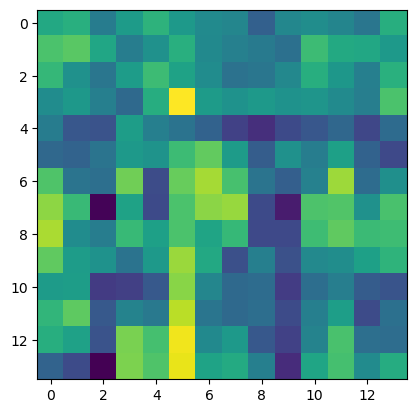

In [40]:
plt.figure()
plt.imshow(temp["embedding__agrifm"][0])

In [17]:
point_to_row = {point_key(row.lon, row.lat): i for i, row in enumerate(df_state.itertuples(index=False))}
vectors_by_model = {}

for pm, npz_path, _ in iter_export_points(EXPORT_ROOT / STATES[0]):
    row_index = point_row_index(pm, point_to_row)
    if row_index is None or not npz_path.exists():
        continue

    with np.load(npz_path, allow_pickle=False) as bundle:
        for model, vec in iter_model_vectors(bundle, pm):
            vectors_by_model.setdefault(model, {})[int(row_index)] = vec

X_by_model = {}
summary_rows = []

for model, row_map in sorted(vectors_by_model.items()):
    dims = {int(vec.shape[0]) for vec in row_map.values()}
    if len(dims) != 1:
        print(f"skip {model}: inconsistent dims {sorted(dims)}")
        continue

    dim = dims.pop()
    X = np.full((len(df_state), dim), np.nan, dtype=np.float32)
    for row_index, vec in row_map.items():
        X[row_index] = vec

    valid_rows = int(np.isfinite(X).all(axis=1).sum())
    X_by_model[model] = X
    summary_rows.append(
        {
            "model": model,
            "dim": dim,
            "valid_rows": valid_rows,
            "coverage": valid_rows / len(df),
        }
    )

embed_df = (
    pd.DataFrame(summary_rows).sort_values("coverage", ascending=False).reset_index(drop=True)
)
if embed_df.empty:
    raise RuntimeError(f"No usable embeddings found in {EXPORT_ROOT}.")

embed_df

,model,dim,valid_rows,coverage
0,agrifm,1024,485,0.190196
1,satmae,1024,485,0.190196
2,satvision,4096,485,0.190196
3,terrafm,768,485,0.190196


In [42]:
X_by_model

{'agrifm': array([[ 0.17647173,  0.6726959 , -1.6722887 , ...,  0.2695747 ,
          0.01873296, -1.3430272 ],
        [ 0.16983034,  0.5545908 , -1.6381649 , ...,  0.39917272,
          0.16020249, -1.2723031 ],
        [ 0.19086471,  0.63132876, -1.6862895 , ...,  0.33861652,
          0.12286901, -1.298508  ],
        ...,
        [ 0.20205028,  0.49395713, -1.7077917 , ...,  0.4301441 ,
          0.21830356, -1.2964739 ],
        [ 0.20587215,  0.46513927, -1.6914797 , ...,  0.46739072,
          0.24167784, -1.2774341 ],
        [ 0.17148958,  0.4669938 , -1.6831913 , ...,  0.47889748,
          0.240384  , -1.2976185 ]], shape=(485, 1024), dtype=float32),
 'satmae': array([[ 1.1538293 ,  0.6443215 , -0.23129147, ...,  0.21659045,
         -0.1551461 , -1.3042909 ],
        [ 1.1756723 ,  0.6307033 , -0.24802196, ...,  0.21904479,
         -0.16331542, -1.3211125 ],
        [ 1.1313839 ,  0.6222649 , -0.21652743, ...,  0.20774315,
         -0.13557741, -1.2781373 ],
        ...,


In [29]:
OutputSpec.grid()

OutputSpec(mode='grid', pooling='mean', grid_orientation='north_up')